<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto de series de tiempo alternativo**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto de series de tiempo alternativo  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Sistema de predicción de ventas**

El objetivo es saber cuánto vamos a vender en el futuro para saber cuánto espacio de almacén necesitaremos.

</div>

----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **sales.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/sales.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Modelado ARIMA
from pmdarima import auto_arima


# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Guardado de modelos
import joblib

In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/sales.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.head(25)

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
5,2022-09-08 17:10:08.079328,60.081865
6,2022-09-09 17:10:08.079328,68.466704
7,2022-09-10 17:10:08.079328,67.765106
8,2022-09-11 17:10:08.079328,70.512261
9,2022-09-12 17:10:08.079328,74.656453


In [3]:
# Estructura del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación inicial**

El dataset contiene información sobre las ventas ocurridas en distintas fechas, con dos variables: una de tipo string (`date`) que representa la dimensión temporal, y otra de tipo numérico (`sales`) que corresponde a la variable objetivo. No se observan valores nulos en el dataset, y los tipos de datos son adecuados, aunque será necesario convertir la variable `date` a formato datetime para poder construir una serie temporal y realizar su análisis.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Construye y analiza la serie temporal**

</div>

In [4]:
# Convertimos la columna date a formato datetime
df["date"] = pd.to_datetime(df["date"])

# Ordenamos por fecha (MUY IMPORTANTE en series temporales)
df = df.sort_values("date")

# Establecemos la fecha como índice
df = df.set_index("date")

# Eliminamos la parte de la hora
df.index = df.index.normalize()

# Se extrae la variable objetivo como una serie temporal univariada, utilizando el índice temporal previamente definido.
ts = df["sales"]

# Visualizamos estructura final
ts.head()

date
2022-09-03    55.292157
2022-09-04    53.803211
2022-09-05    58.141693
2022-09-06    64.530899
2022-09-07    66.013633
Freq: D, Name: sales, dtype: float64

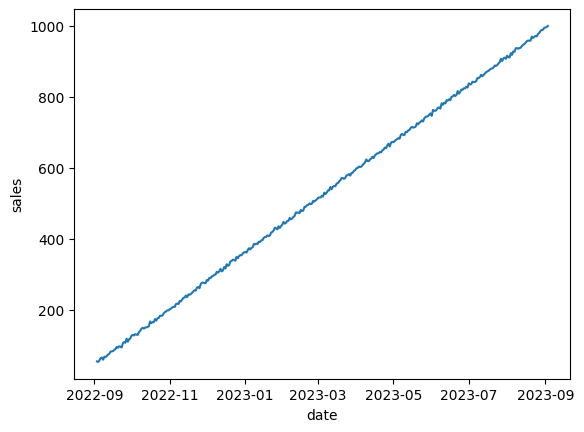

In [5]:
# Graficamos
sns.lineplot(data=ts)
plt.show()

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Pregunta 1: ¿Cuál es el tensor de la serie temporal?**

Nota: Un tensor en una serie temporal es la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes...

</div>

In [6]:
# Inferimos la frecuencia temporal de la serie para determinar su granularidad (tensor)
ts.index.inferred_freq

'D'

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

#### **- Respuesta 1 -**

El tensor de la serie temporal es diario, ya que las fechas muestran observaciones consecutivas día a día. Esto se confirma además mediante la frecuencia inferida del índice ('D').

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Pregunta 2: ¿Cuál es la tendencia?**

</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

#### **- Respuesta 2 -**

Se observa una tendencia claramente creciente en la serie temporal, ya que los valores de ventas aumentan de forma sostenida a lo largo del tiempo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Pregunta 3: ¿Es estacionaria?**

</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

#### **- Respuesta 3 -**

La serie temporal no es estacionaria, ya que presenta una tendencia claramente creciente en el tiempo. la presencia de tendencia es suficiente para romper la estacionariedad, no es necesario analizar otras propiedades para concluirlo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Pregunta 4: ¿Existe variabilidad o presencia de ruido?**

</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

#### **- Respuesta 4 -**

Se observa una variabilidad muy baja en la serie temporal, ya que los valores siguen una tendencia creciente prácticamente lineal, con ligeras fluctuaciones. Esto indica una presencia mínima de ruido en los datos.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Entrena un ARIMA**

</div>

In [7]:
# Calculamos la diferencia entre cada valor y el anterior para eliminar la tendencia creciente
# Ahora la serie representa cómo varían las ventas en el tiempo en lugar de su valor total
ts_stationary = ts.diff().dropna()

# Visualizamos los primeros registros de la serie diferenciada
ts_stationary.head()

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
Freq: D, Name: sales, dtype: float64

In [8]:
# Aplicamos la prueba de Dickey-Fuller para comprobar si la serie diferenciada es estacionaria
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    # Ejecutamos la prueba ADF sobre la serie temporal
    dftest = adfuller(timeseries, autolag="AIC")
    
    # Organizamos los resultados principales en una serie para visualizarlos mejor
    dfoutput = pd.Series(
        dftest[0:4],
        index=["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"]
    )
    
    # Añadimos los valores críticos de referencia
    for key, value in dftest[4].items():
        dfoutput[f"Critical Value ({key})"] = value
    
    return dfoutput

# Comprobamos si la serie transformada puede considerarse estacionaria
test_stationarity(ts_stationary)

Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota:**
El análisis previo de estacionariedad no es redundante, sino que permite comprender el comportamiento de la serie antes de aplicar modelos automáticos.

</div>

In [9]:
# Entrenamos el modelo ARIMA utilizando la serie original, ya que auto_arima se encarga de aplicar la diferenciación necesaria internamente
# Se considera estacionalidad semanal (m=7) por tratarse de datos diarios, y se activa trace=True para visualizar el proceso de selección de hiperparámetros
model_full = auto_arima(ts, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.92 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=2209.657, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.07 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.31 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.23 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.11 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.71 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=1.16 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.72 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.32 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.65 sec
 ARIMA(2,1,0)(1,0,2)[7] intercept   : AIC=1

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Mejor parametrización**
El modelo auto_arima ha seleccionado como mejor configuración ARIMA(4,1,1)(0,0,1)[7], indicando la necesidad de aplicar una diferenciación (d=1) para hacer la serie estacionaria. Esto coincide con el análisis previo realizado, donde se detectó que la serie no era estacionaria y requería transformación. Además, se identifica un componente estacional semanal (m=7), coherente con la naturaleza diaria de los datos.
</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Predice con el conjunto de test**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Nota:**

Aunque el objetivo final es predecir valores futuros, primero se valida el modelo utilizando un conjunto de test histórico, simulando un escenario real donde se predicen datos no vistos y se comparan con los valores reales para evaluar su rendimiento.

</div>

In [10]:
# Dividimos la serie en entrenamiento (80%) y test (20%)
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

In [11]:
# Entrenamos el modelo con train
model_train = auto_arima(train, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1477.795, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1675.428, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1574.824, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1472.428, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1763.761, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1475.165, Time=0.10 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.76 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=inf, Time=0.68 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=1471.251, Time=0.52 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=1472.463, Time=0.83 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=1470.355, Time=0.90 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.24 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=0.89 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=1678.420, Time=0.24 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=1472.848, T

In [12]:
# Predecimos el futuro con el mismo tamaño de test
forecast_test = model_train.predict(n_periods=len(test))

In [16]:
# Calculamos métricas de error para evaluar el rendimiento del modelo
# Comparamos las predicciones generadas con los valores reales del conjunto de test
mae = mean_absolute_error(test, forecast_test)
mse = mean_squared_error(test, forecast_test)

# Mostramos los resultados de las métricas
print(mae)
print(mse)

2.161270397453276
7.4511055482761135


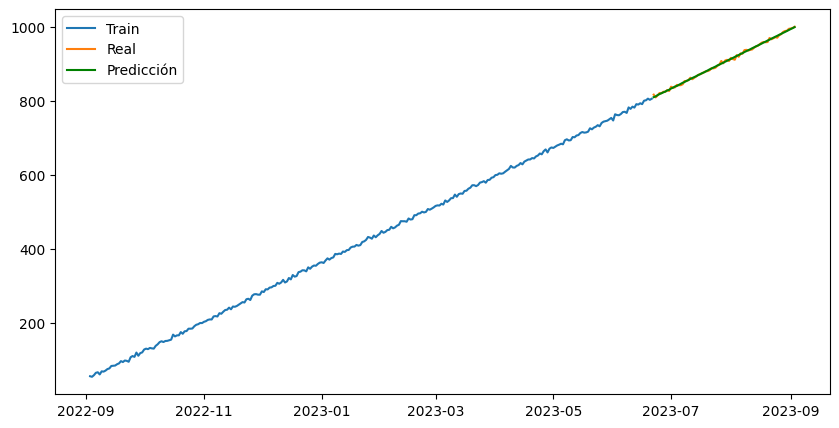

In [17]:
# Representamos gráficamente los datos de entrenamiento, los valores reales del test y las predicciones del modelo
# Esto nos permite visualizar qué tan bien se ajusta el modelo a los datos reales
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Real")
plt.plot(test.index, forecast_test, label="Predicción", color="green")
plt.legend()
plt.show()

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

#### **Observación final**

El modelo ARIMA ha sido evaluado utilizando un conjunto de test, comparando las predicciones generadas con los valores reales de la serie temporal.

Las métricas obtenidas (MAE ≈ 2.16 y MSE ≈ 7.45) indican que el error de predicción es muy bajo. En términos prácticos, esto significa que el modelo se equivoca en aproximadamente 2 unidades de ventas de media, lo cual es un error pequeño en relación con el rango total de los datos.

A nivel visual, la gráfica muestra que la línea de predicción (verde) se superpone casi completamente con los valores reales (naranja), lo que confirma que el modelo captura correctamente el comportamiento de la serie temporal.

En conjunto, tanto las métricas como la representación gráfica indican que el modelo tiene un buen rendimiento y es capaz de generar predicciones precisas sobre los datos. Esto sugiere que el modelo es adecuado para su uso en predicciones futuras, como estimar la demanda y dimensionar el espacio necesario en el nuevo almacén.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Guarda el modelo**

</div>

In [18]:
# Guardamos el modelo final entrenado con toda la serie temporal

joblib.dump(model_full, "../models/arima_sales_model.sav")

['../models/arima_sales_model.sav']